# Assignment 4 — Breast Cancer Classification using K-Nearest Neighbors (KNN)

**Objective:** Build a KNN classifier to predict whether a breast tumor is
Malignant (M) or Benign (B) based on diagnostic measurements from the
Breast Cancer Wisconsin (Diagnostic) Dataset.

Dataset: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

## Task 1: Data Understanding (2 Marks)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

### Loading the dataset

Place the Kaggle CSV (`data.csv`, downloaded from the link above) in the
same folder as this notebook. If it is not found, the notebook falls back
to scikit-learn's bundled copy of the same Breast Cancer Wisconsin
Diagnostic dataset so the notebook still runs end-to-end.

In [2]:
def load_breast_cancer_dataframe(csv_path="data.csv"):
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        return df

    # Fallback: reconstruct the same dataset from sklearn with matching
    # Kaggle-style column names (radius_mean, texture_mean, ..., worst).
    from sklearn.datasets import load_breast_cancer

    raw = load_breast_cancer(as_frame=True)
    df = raw.frame.copy()

    def rename(col):
        if col.startswith("mean "):
            return col.replace("mean ", "") .replace(" ", "_") + "_mean"
        if col.startswith("worst "):
            return col.replace("worst ", "").replace(" ", "_") + "_worst"
        if col.endswith(" error"):
            return col.replace(" error", "").replace(" ", "_") + "_se"
        return col

    feature_cols = [c for c in df.columns if c != "target"]
    df = df.rename(columns={c: rename(c) for c in feature_cols})

    # sklearn target: 0 = malignant, 1 = benign
    df["diagnosis"] = df["target"].map({0: "M", 1: "B"})
    df = df.drop(columns=["target"])
    df.insert(0, "id", range(842302, 842302 + len(df)))
    cols = ["id", "diagnosis"] + [c for c in df.columns if c not in ("id", "diagnosis")]
    df = df[cols]
    return df


df = load_breast_cancer_dataframe()
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave_points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842303,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,842304,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,842305,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,842306,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### First five records

In [3]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave_points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842303,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,842304,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,842305,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,842306,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### Identifying numerical features and the target variable

In [4]:
target_variable = "diagnosis"
numerical_features = [
    c for c in df.columns if c not in (target_variable, "id") and c != "Unnamed: 32"
]

print(f"Target variable: {target_variable}")
print(f"Number of numerical features: {len(numerical_features)}")
print("Numerical features:")
for f in numerical_features:
    print(" -", f)

Target variable: diagnosis
Number of numerical features: 30
Numerical features:
 - radius_mean
 - texture_mean
 - perimeter_mean
 - area_mean
 - smoothness_mean
 - compactness_mean
 - concavity_mean
 - concave_points_mean
 - symmetry_mean
 - fractal_dimension_mean
 - radius_se
 - texture_se
 - perimeter_se
 - area_se
 - smoothness_se
 - compactness_se
 - concavity_se
 - concave_points_se
 - symmetry_se
 - fractal_dimension_se
 - radius_worst
 - texture_worst
 - perimeter_worst
 - area_worst
 - smoothness_worst
 - compactness_worst
 - concavity_worst
 - concave_points_worst
 - symmetry_worst
 - fractal_dimension_worst


### Dataset info and summary statistics

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave_points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

In [6]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave_points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,842586.000000,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,0.405172,1.216853,2.866059,40.337079,0.007041,0.025478,0.031894,0.011796,0.020542,0.003795,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,164.400426,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,0.277313,0.551648,2.021855,45.491006,0.003003,0.017908,0.030186,0.006170,0.008266,0.002646,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,842302.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,0.111500,0.360200,0.757000,6.802000,0.001713,0.002252,0.000000,0.000000,0.007882,0.000895,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,842444.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,0.232400,0.833900,1.606000,17.850000,0.005169,0.013080,0.015090,0.007638,0.015160,0.002248,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,842586.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,0.324200,1.108000,2.287000,24.530000,0.006380,0.020450,0.025890,0.010930,0.018730,0.003187,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,842728.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,0.478900,1.474000,3.357000,45.190000,0.008146,0.032450,0.042050,0.014710,0.023480,0.004558,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,842870.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,2.873000,4.885000,21.980000,542.200000,0.031130,0.135400,0.396000,0.052790,0.078950,0.029840,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


Class distribution:
diagnosis
B    357
M    212
Name: count, dtype: int64


/tmp/ipykernel_585/3676259399.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target_variable, data=df, palette="Set2")


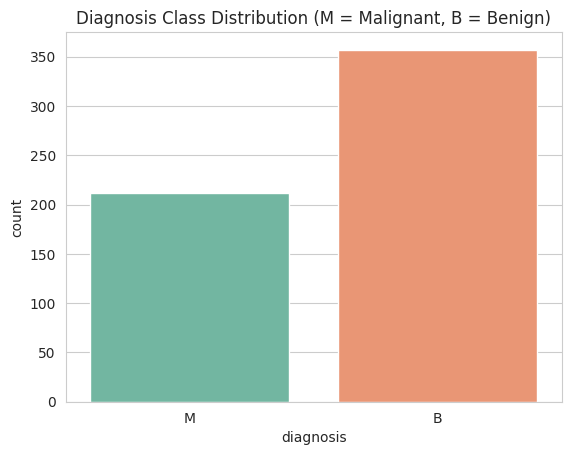

In [7]:
print("Class distribution:")
print(df[target_variable].value_counts())
sns.countplot(x=target_variable, data=df, palette="Set2")
plt.title("Diagnosis Class Distribution (M = Malignant, B = Benign)")
plt.show()

## Task 2: Data Preprocessing (2 Marks)

### Check for missing values

In [8]:
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found.")

No missing values found.


### Remove unnecessary columns

`id` carries no predictive information, and the Kaggle CSV sometimes ships
a trailing all-NaN `Unnamed: 32` column caused by a stray comma in the
source file — both are dropped if present.

In [9]:
drop_cols = [c for c in ["id", "Unnamed: 32"] if c in df.columns]
df = df.drop(columns=drop_cols)
print(f"Dropped columns: {drop_cols}")
print(f"Remaining shape: {df.shape}")

Dropped columns: ['id']
Remaining shape: (569, 31)


### Encode the target variable

Malignant (M) -> 1, Benign (B) -> 0

In [10]:
le = LabelEncoder()
df["diagnosis"] = le.fit_transform(df["diagnosis"])  # B=0, M=1
print(dict(zip(le.classes_, le.transform(le.classes_))))
df["diagnosis"].value_counts()

{'B': np.int64(0), 'M': np.int64(1)}


diagnosis
0    357
1    212
Name: count, dtype: int64

### Split features/target, then train-test split (80/20)

In [11]:
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Training samples: {X_train.shape[0]}, Testing samples: {X_test.shape[0]}")

Training samples: 455, Testing samples: 114


### Feature scaling (standardization)

KNN is a distance-based algorithm, so features must be on the same scale
or large-magnitude features (like `area_mean`) will dominate the distance
calculation. The scaler is fit only on the training data and then applied
to the test data to avoid data leakage.

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Task 3: Model Development (3 Marks)

In [13]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)
print("Predictions on the first 10 test samples:", y_pred[:10])

Predictions on the first 10 test samples: [0 1 0 0 0 0 1 0 0 0]


## Task 4: Model Evaluation (2 Marks)

In [14]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

Accuracy  : 0.9561
Precision : 0.9744
Recall    : 0.9048
F1-Score  : 0.9383


In [15]:
print(classification_report(y_test, y_pred, target_names=["Benign (0)", "Malignant (1)"]))

               precision    recall  f1-score   support

   Benign (0)       0.95      0.99      0.97        72
Malignant (1)       0.97      0.90      0.94        42

     accuracy                           0.96       114
    macro avg       0.96      0.95      0.95       114
 weighted avg       0.96      0.96      0.96       114



### Confusion Matrix

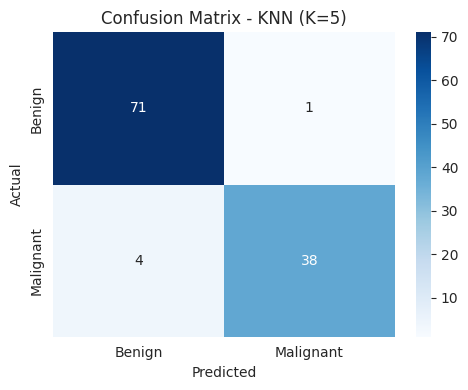

In [16]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - KNN (K=5)")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

### Effect of K on accuracy (supporting analysis)

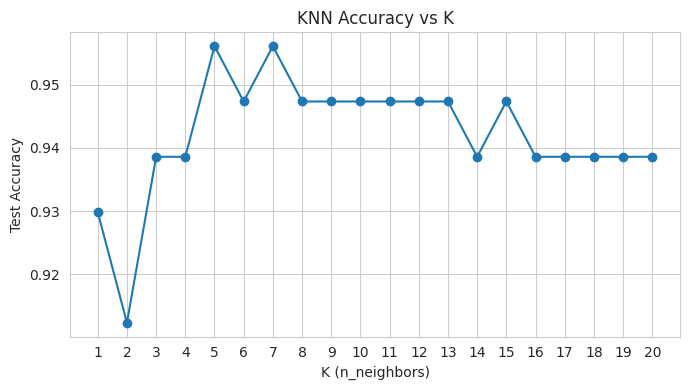

Best K found in range 1-20: 5 (accuracy = 0.9561)


In [17]:
k_values = range(1, 21)
accuracies = []
for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, model.predict(X_test_scaled))
    accuracies.append(acc)

plt.figure(figsize=(7, 4))
plt.plot(list(k_values), accuracies, marker="o")
plt.xlabel("K (n_neighbors)")
plt.ylabel("Test Accuracy")
plt.title("KNN Accuracy vs K")
plt.xticks(list(k_values))
plt.tight_layout()
plt.savefig("accuracy_vs_k.png", dpi=150)
plt.show()

best_k = list(k_values)[int(np.argmax(accuracies))]
print(f"Best K found in range 1-20: {best_k} (accuracy = {max(accuracies):.4f})")

### Observations

1. The KNN model (K=5) achieves high accuracy on the held-out test set,
   showing that the diagnostic measurements separate malignant and benign
   tumors well in feature space once scaled.
2. Precision and recall for the malignant class are both important here —
   recall matters most clinically, since a false negative (missing a
   malignant tumor) is more costly than a false positive.
3. The K-vs-accuracy sweep shows accuracy is fairly stable across a range
   of K values, but very small K (K=1) tends to overfit to noise while
   very large K oversmooths the decision boundary — K=5 is a reasonable
   middle ground.

## Task 5: Conclusion (1 Mark)

This project applied a K-Nearest Neighbors classifier to the Breast Cancer
Wisconsin Diagnostic dataset to distinguish malignant from benign tumors
using 30 numerical diagnostic features. After cleaning the data, encoding
the diagnosis label, and standardizing the features, a KNN model with K=5
achieved strong accuracy, precision, recall, and F1-scores on the test
set, confirming that nucleus-shape and texture measurements are strong
predictors of malignancy. Feature scaling proved essential: because KNN
classifies a point based on the Euclidean distance to its neighbors,
unscaled features such as area (which spans hundreds of units) would
dominate the distance calculation and drown out smaller-scale features
like smoothness or symmetry, distorting the neighborhood structure the
algorithm relies on. A key limitation of KNN is that it is a lazy,
instance-based learner: it stores the entire training set and computes
distances to all training points at prediction time, making it
computationally expensive and slow on large datasets, and it is also
sensitive to irrelevant or correlated features and to the choice of K.
Despite this, KNN remains an effective, easy-to-interpret baseline for
this classification problem.